In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = df.drop(columns=['customerID'])

df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df = df.dropna()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim Veri Boyutu: {X_train.shape}")
print(f"Test Veri Boyutu: {X_test.shape}\n")

Eğitim Veri Boyutu: (5625, 30)
Test Veri Boyutu: (1407, 30)



In [5]:
dt_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

print("==================================================")
print("             MODEL PERFORMANS SONUÇLARI           ")
print("==================================================")
print(f"Karar Ağacı - Eğitim Başarısı (Train Acc): {accuracy_score(y_train, dt_train_pred):.4f}")
print(f"Karar Ağacı - Test Başarısı (Test Acc)  : {accuracy_score(y_test, dt_test_pred):.4f}")
print("--------------------------------------------------")
print(f"Rastgele Orman - Eğitim Başarısı (Train Acc): {accuracy_score(y_train, rf_train_pred):.4f}")
print(f"Rastgele Orman - Test Başarısı (Test Acc)  : {accuracy_score(y_test, rf_test_pred):.4f}")
print("==================================================\n")

print("Rastgele Orman Detaylı Test Raporu:")
print(classification_report(y_test, rf_test_pred))

             MODEL PERFORMANS SONUÇLARI           
Karar Ağacı - Eğitim Başarısı (Train Acc): 0.9988
Karar Ağacı - Test Başarısı (Test Acc)  : 0.7186
--------------------------------------------------
Rastgele Orman - Eğitim Başarısı (Train Acc): 0.9988
Rastgele Orman - Test Başarısı (Test Acc)  : 0.7896

Rastgele Orman Detaylı Test Raporu:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



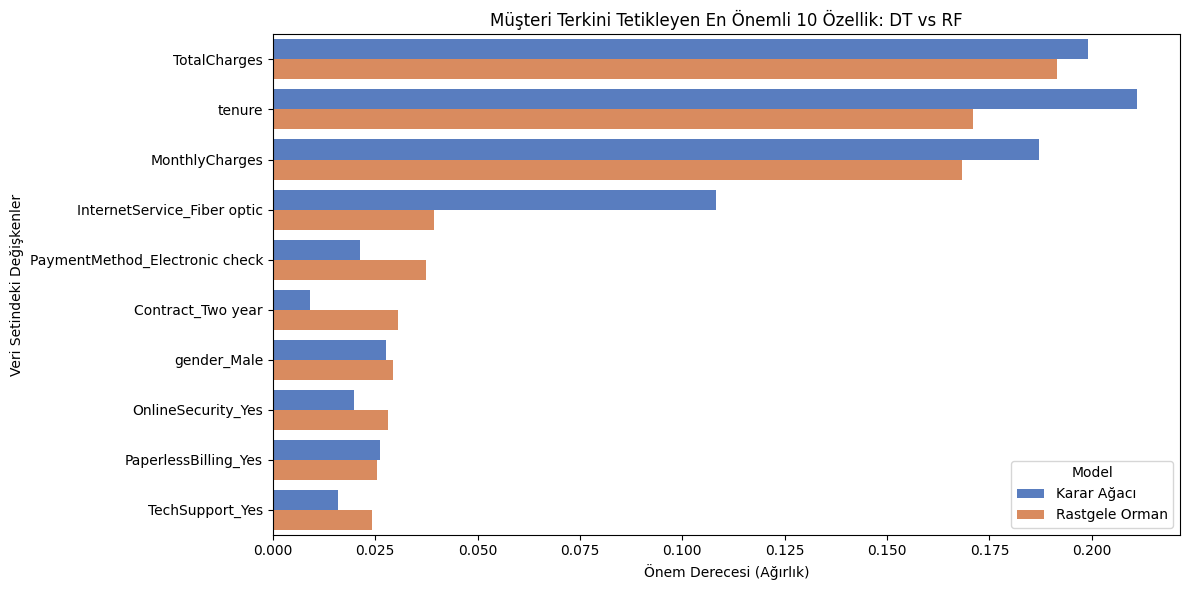

In [8]:
dt_importances = dt_model.feature_importances_
rf_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Özellik': X.columns,
    'Karar Ağacı': dt_importances,
    'Rastgele Orman': rf_importances
}).sort_values(by='Rastgele Orman', ascending=False).head(10)


importance_melted = pd.melt(importance_df, id_vars="Özellik", var_name="Model", value_name="Önem Derecesi")

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_melted, x="Önem Derecesi", y="Özellik", hue="Model", palette="muted")
plt.title("Müşteri Terkini Tetikleyen En Önemli 10 Özellik: DT vs RF")
plt.xlabel("Önem Derecesi (Ağırlık)")
plt.ylabel("Veri Setindeki Değişkenler")
plt.tight_layout()
plt.show()

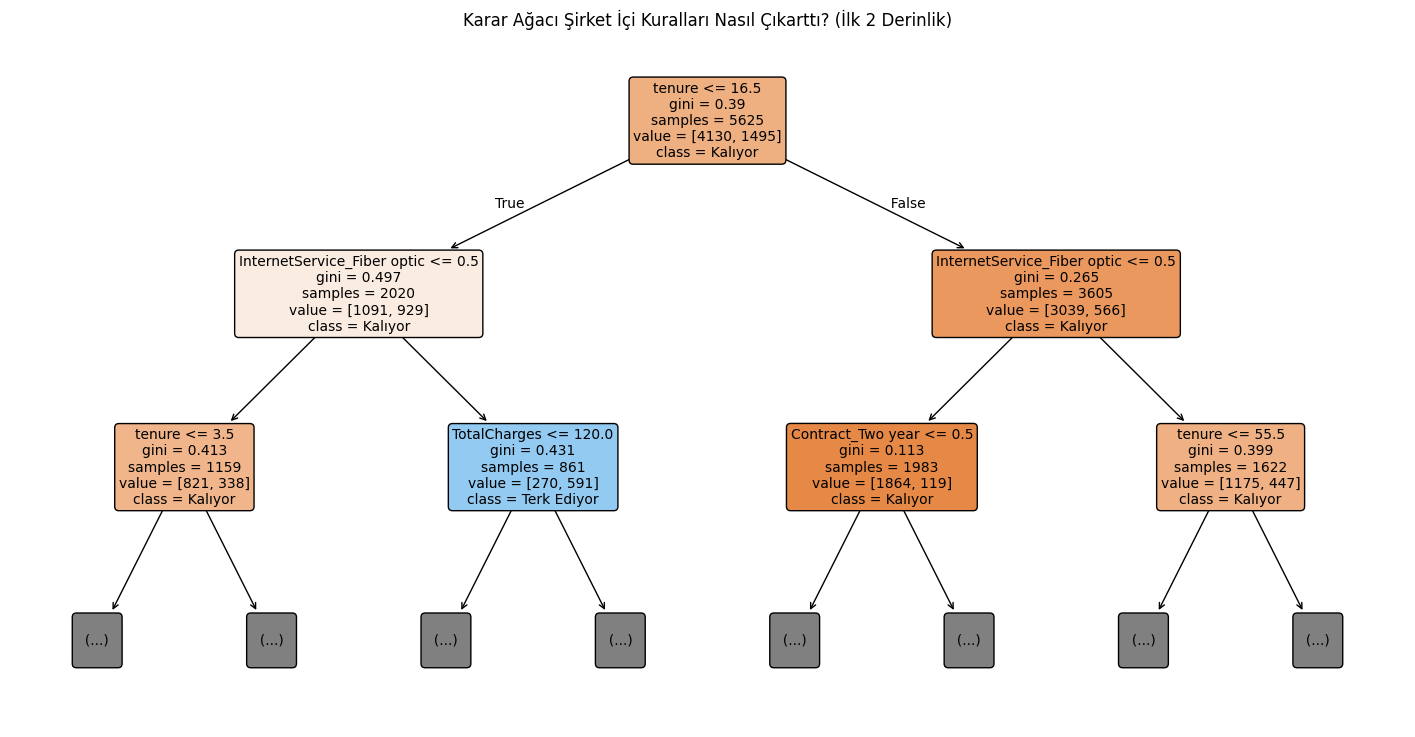

In [7]:
plt.figure(figsize=(18, 9))
plot_tree(dt_model, max_depth=2, feature_names=X.columns, class_names=['Kalıyor', 'Terk Ediyor'], filled=True, rounded=True, fontsize=10)
plt.title("Karar Ağacı Şirket İçi Kuralları Nasıl Çıkarttı? (İlk 2 Derinlik)")
plt.show()